Purpose: Aggregate login timetamps from json file into 15 minute intervals, and visualize and describe the resulting time series of login counts in ways that best characterize the underlying patterns of the demand. 

Start by importing libraries and data

In [1]:
#import likely useful libraries
import numpy as np
import pandas as pd
import datetime as dt
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#confirm directory
os.listdir()

['.ipynb_checkpoints',
 'logins.json',
 'ultimate_data_challenge.json',
 'ultimate_data_science_challenge (1).pdf',
 'ultimate_part1.ipynb']

In [3]:
#import data
dflogins = pd.read_json('logins.json')

#overview of data
dflogins.head()

,login_time
0,1970-01-01 20:13:18
1,1970-01-01 20:16:10
2,1970-01-01 20:16:37
3,1970-01-01 20:16:36
4,1970-01-01 20:26:21


In [4]:
dflogins.describe()

,login_time
count,93142
mean,1970-02-26 19:09:39.779648278
min,1970-01-01 20:12:16
25%,1970-02-04 10:37:19.750000
50%,1970-03-01 06:33:05.500000
75%,1970-03-22 04:01:10.750000
max,1970-04-13 18:57:38


It looks like we have 3 months worth of data, however, the start date of 01-01-1970 is suspisious. Since this is the Unix epoch, it may mean that this is not the actual date, but a default placeholder, which means it is likely that only the time values are valid. This also means that we don't have the actual day of the logins, so we cannot learn anything about day of week patterns or weekday vs weekend.

Now that we have looked at the data, we can start to create the 15 minute intervals

In [5]:
#create a new column that rounds the login times to 15 minute "buckets"
dflogins["login_15min"] = dflogins["login_time"].dt.floor("15min")
dflogins.head()

,login_time,login_15min
0,1970-01-01 20:13:18,1970-01-01 20:00:00
1,1970-01-01 20:16:10,1970-01-01 20:15:00
2,1970-01-01 20:16:37,1970-01-01 20:15:00
3,1970-01-01 20:16:36,1970-01-01 20:15:00
4,1970-01-01 20:26:21,1970-01-01 20:15:00


In [6]:
#aggregate the buckets
counts = dflogins.groupby("login_15min").size().reset_index(name="login_count")
counts.head()

,login_15min,login_count
0,1970-01-01 20:00:00,2
1,1970-01-01 20:15:00,6
2,1970-01-01 20:30:00,9
3,1970-01-01 20:45:00,7
4,1970-01-01 21:00:00,1


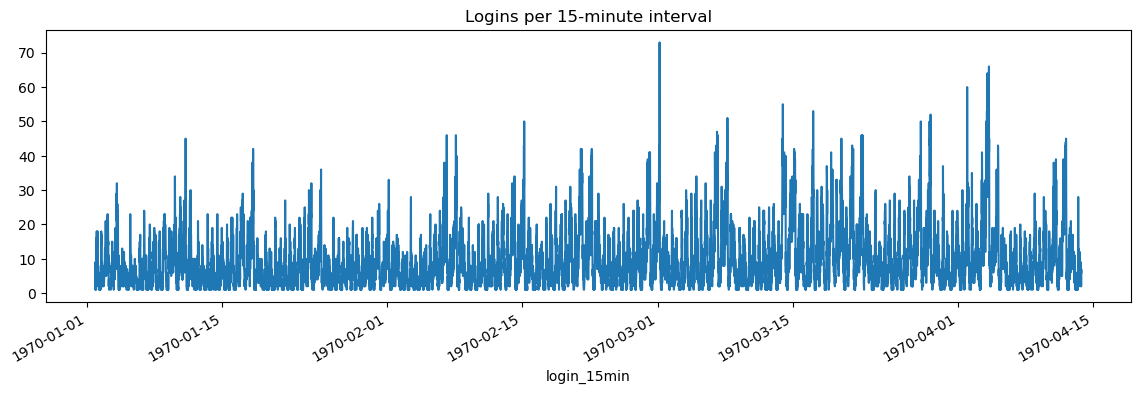

In [7]:
#plot the data
counts.set_index("login_15min")["login_count"].plot(kind="line", figsize=(14,4)) 
plt.title("Logins per 15‑minute interval") 
plt.show()

This graph shows every 15 minute interval for the 3 month period. As mentioned earlier, we don't want to focus on the time over the course of the three months since the dates are likely placeholders. Instead, we want to focus on the daily paterns, so let's adjust the data to combine all the days together and just focus on the time of day

In [9]:
#create new column that gives every day the same date
dflogins["login_time_same_date"] = dflogins["login_time"].apply( lambda x: x.replace(year=1970, month=1, day=1))
dflogins.tail()

,login_time,login_15min,login_time_same_date
93137,1970-04-13 18:50:19,1970-04-13 18:45:00,1970-01-01 18:50:19
93138,1970-04-13 18:43:56,1970-04-13 18:30:00,1970-01-01 18:43:56
93139,1970-04-13 18:54:02,1970-04-13 18:45:00,1970-01-01 18:54:02
93140,1970-04-13 18:57:38,1970-04-13 18:45:00,1970-01-01 18:57:38
93141,1970-04-13 18:54:23,1970-04-13 18:45:00,1970-01-01 18:54:23


In [11]:
#create the 15 minute interval buckets using the adjusted same-date column
dflogins["login_time_15min"] = dflogins["login_time_same_date"].dt.floor("15min")
dflogins.tail()

,login_time,login_15min,login_time_same_date,login_time_15min
93137,1970-04-13 18:50:19,1970-04-13 18:45:00,1970-01-01 18:50:19,1970-01-01 18:45:00
93138,1970-04-13 18:43:56,1970-04-13 18:30:00,1970-01-01 18:43:56,1970-01-01 18:30:00
93139,1970-04-13 18:54:02,1970-04-13 18:45:00,1970-01-01 18:54:02,1970-01-01 18:45:00
93140,1970-04-13 18:57:38,1970-04-13 18:45:00,1970-01-01 18:57:38,1970-01-01 18:45:00
93141,1970-04-13 18:54:23,1970-04-13 18:45:00,1970-01-01 18:54:23,1970-01-01 18:45:00


In [13]:
##aggregate the buckets 
countsTime = dflogins.groupby("login_time_15min").size().reset_index(name="login_count")

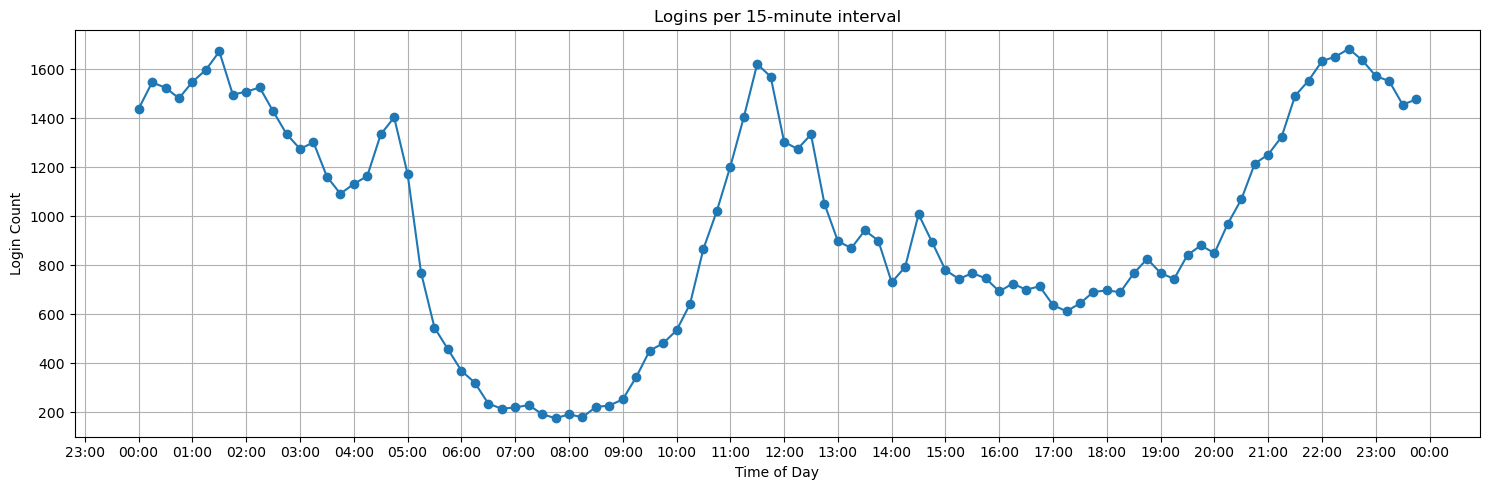

In [14]:
#plot the data
import matplotlib.dates as mdates

# Force x-axis to be real datetimes
x = pd.to_datetime(countsTime["login_time_15min"])

#create the plot
plt.figure(figsize=(15,5))
plt.plot(x, countsTime["login_count"],marker='o')

#add/adjust x tick marks to be hourly
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=1))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

plt.title("Logins per 15‑minute interval")
plt.xlabel("Time of Day")
plt.ylabel("Login Count")
plt.grid(True)
plt.tight_layout()
plt.show()


This is a good start. It shows that there is a period of little demand between 05:30 and 10:00. It also shows what initially appears to be 3 periods of high demand (00:00-0:230, 11:00-12:30, and 21:00-00:00), however since this is a daily cycle, we have to realize that the graph actually wraps back around to the front. So in reality, there are only two major periods of demand (21:00-02:30, and 11:00-12:30). Lets see if we can make a better graph to visualize this.

In [15]:
#create the initial steps for a Polar Clock

# Ensure login_time is datetime64
countsTime["login_time_15min"] = pd.to_datetime(countsTime["login_time_15min"])

# Convert to minutes since midnight
minutes = countsTime["login_time_15min"].dt.hour * 60 + countsTime["login_time_15min"].dt.minute

# Convert minutes → radians
angles = 2 * np.pi * (minutes / 1440)

# Values to plot
values = countsTime["login_count"].values


Now that we have the buidling blocks for a polar clock plot, we can plot it

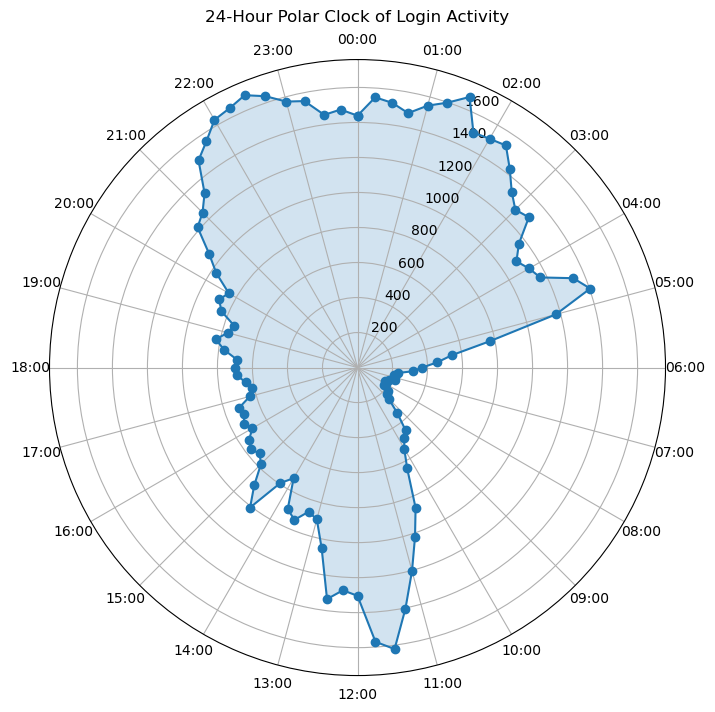

In [16]:
# Close the circle by repeating the first point
angles = np.append(angles, angles[0])
values = np.append(values, values[0])

# Plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.plot(angles, values, marker="o")
ax.fill(angles, values, alpha=0.2)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)

# Clock-style labels
ax.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)])

ax.set_title("24‑Hour Polar Clock of Login Activity", va='bottom')
plt.show()


This is a good start, but for variety, let's try it again, this time as a bar polar clock

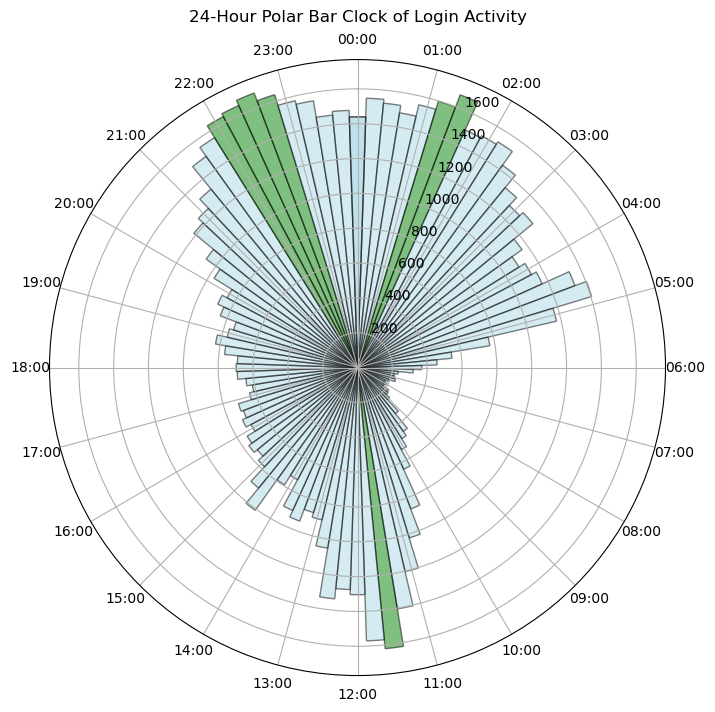

In [17]:

# Width of each bar (15 minutes in radians)
bar_width = 2 * np.pi * (15 / 1440)

# Identify the top 5 values 
top5_idx = np.argsort(values)[-5:]


#create Plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)

colors = ["green" if v > 1590 else "lightblue" for v in values]

# Draw bars
ax.bar(angles, values, width=bar_width, alpha=0.5, color=colors, edgecolor="black",)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)


# Clock-style hour labels
ax.set_xticks(np.linspace(0, 2*np.pi, 24, endpoint=False))
ax.set_xticklabels([f"{h:02d}:00" for h in range(24)])


ax.set_title("24‑Hour Polar Bar Clock of Login Activity", va='bottom')
plt.show()


Based on a first look of these plots, there seems to be a pattern throughtout the day: A period of high demand, followed by a long period of some demand, followed by a longer period of high demand, followed by a period of low demand. This cycle looks demand throughout a workday: high demand before work, some demand during the day (while people are working), high demand as people end work until they go to sleep, and little demand overnight while people are sleeping). What is odd about this is that while the cycle matches (approximately 8 hours of moderate usage during the workday), the timing does not (people don't usually get up around 11-12). However, remembering that the date was the default Unix time, it is likely that the time also defaulted to UTC 0 time. If we offset the times to adjust to a normal person's workday of around 9 to 5, then the plot matches perfectly for people living in UTCs between -5 to -7, which could be the geographical location of Central/Eastern USA (or other locations within UTC -5 to UTC -7)

Now let's see if we can reverse engineer the weekday vs the weekend to see if any patterns arise. Even though we have already said the dates were wrong, the days still follow each other. If we graph a 7 day period, or multiple 7 day periods, we might be able to see if there is a defferent demand on two consecutive days, thereby suggesting that those two days are the weekend.